## Testing the general workflow of our Optsne implementation and comparing it to a standard openTSNE implementation

**Purpose:** in this notebook, we primarily verify the functionality of our custom functions and ensure consistency between our custom workflow and the original openTSNE library methods.

In [16]:
from sklearn.datasets import make_swiss_roll, load_digits
from python_tsne_utils import utils
import importlib
importlib.reload(utils)
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
INITIAL_ALPHA = 1.

### Load toy data (Swiss Roll with 500 data points)

In [3]:
X, colors = make_swiss_roll(n_samples=500, noise=0.2)


### Check individual functions

In [4]:
# Check t-SNE initialization
importlib.reload(utils)
initial_embedding, affinities = utils.initialize_tsne_embedding(X=X, initial_alpha=INITIAL_ALPHA)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...


In [5]:
# Check early exaggeration phase
importlib.reload(utils)
embedding = utils.run_early_exaggeration_phase(initial_embedding=initial_embedding, initial_alpha=INITIAL_ALPHA)

Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...


### Check the complete main function

In [ ]:
# Load toy data again for clean example
X, colors = make_swiss_roll(n_samples=500, noise=0.0)

In [7]:
# Run the custom t-SNE workflow implementation without optimization for alpha
importlib.reload(utils)
tsne_result_custom = utils.tsne_with_dof_optimisation(X = X, n_iter=500, initial_alpha=INITIAL_ALPHA, dataset_name='SwissRoll')

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 500 iterations...
Iteration 0 out of 500 done
Current KL divergence: 1.9432524107567506
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 1.5308176736030994
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 1.2207657897127309
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 1.0155118187788155
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 500 done
Current KL divergence: 0.8751892427781041
Current al

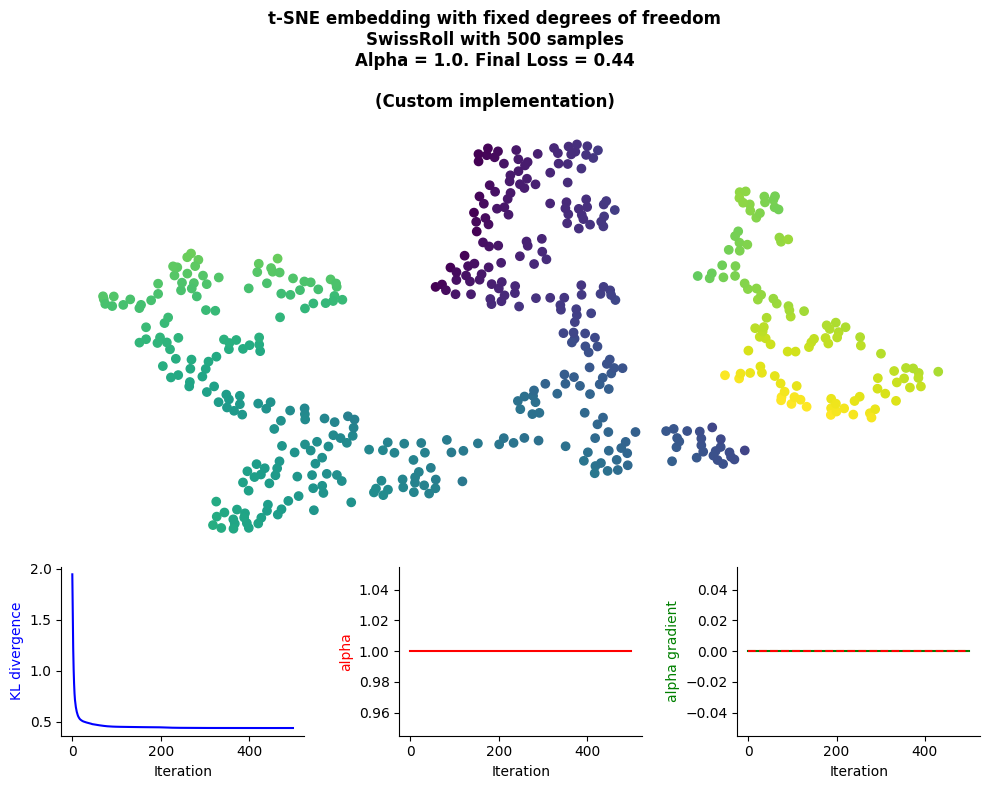

In [8]:
# plot results
importlib.reload(utils)
utils.plot_tsne_result(data= tsne_result_custom, labels= colors, additional_title='(Custom implementation)')

In [9]:
# Run the reference openTSNE implementation
importlib.reload(utils)
tsne_result = utils.run_reference_tsne(X=X, n_iter=500, fixed_alpha =1, dataset_name='SwissRoll')

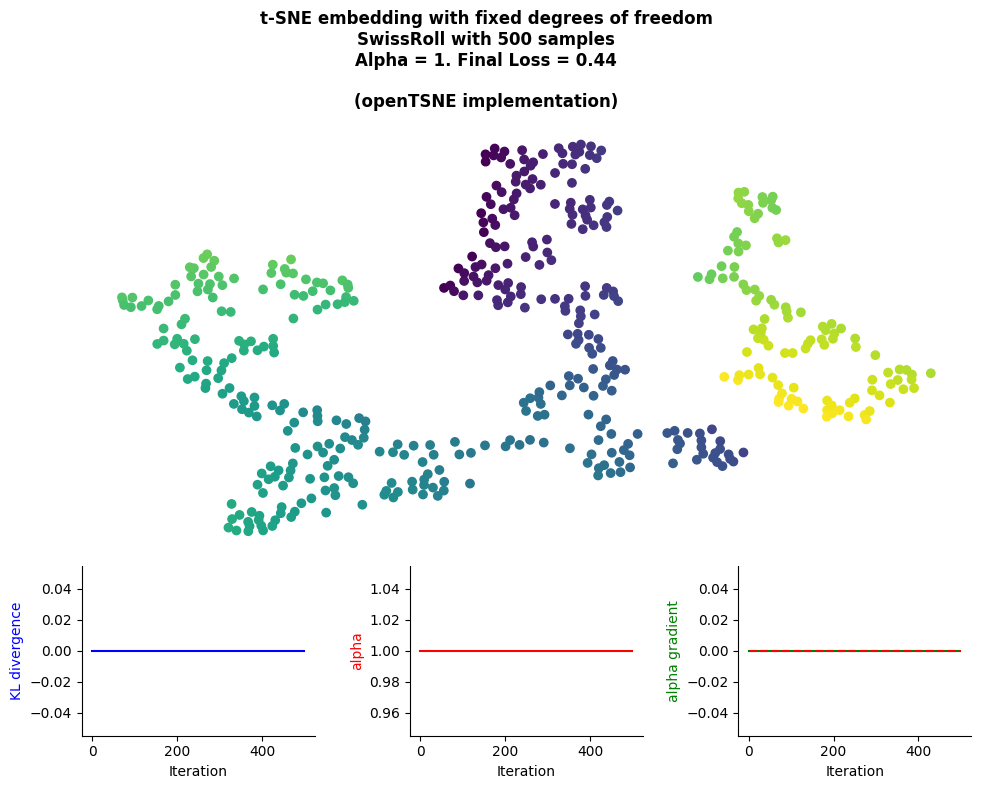

In [10]:
# plot results
utils.plot_tsne_result(data= tsne_result, labels= colors, additional_title='(openTSNE implementation)')

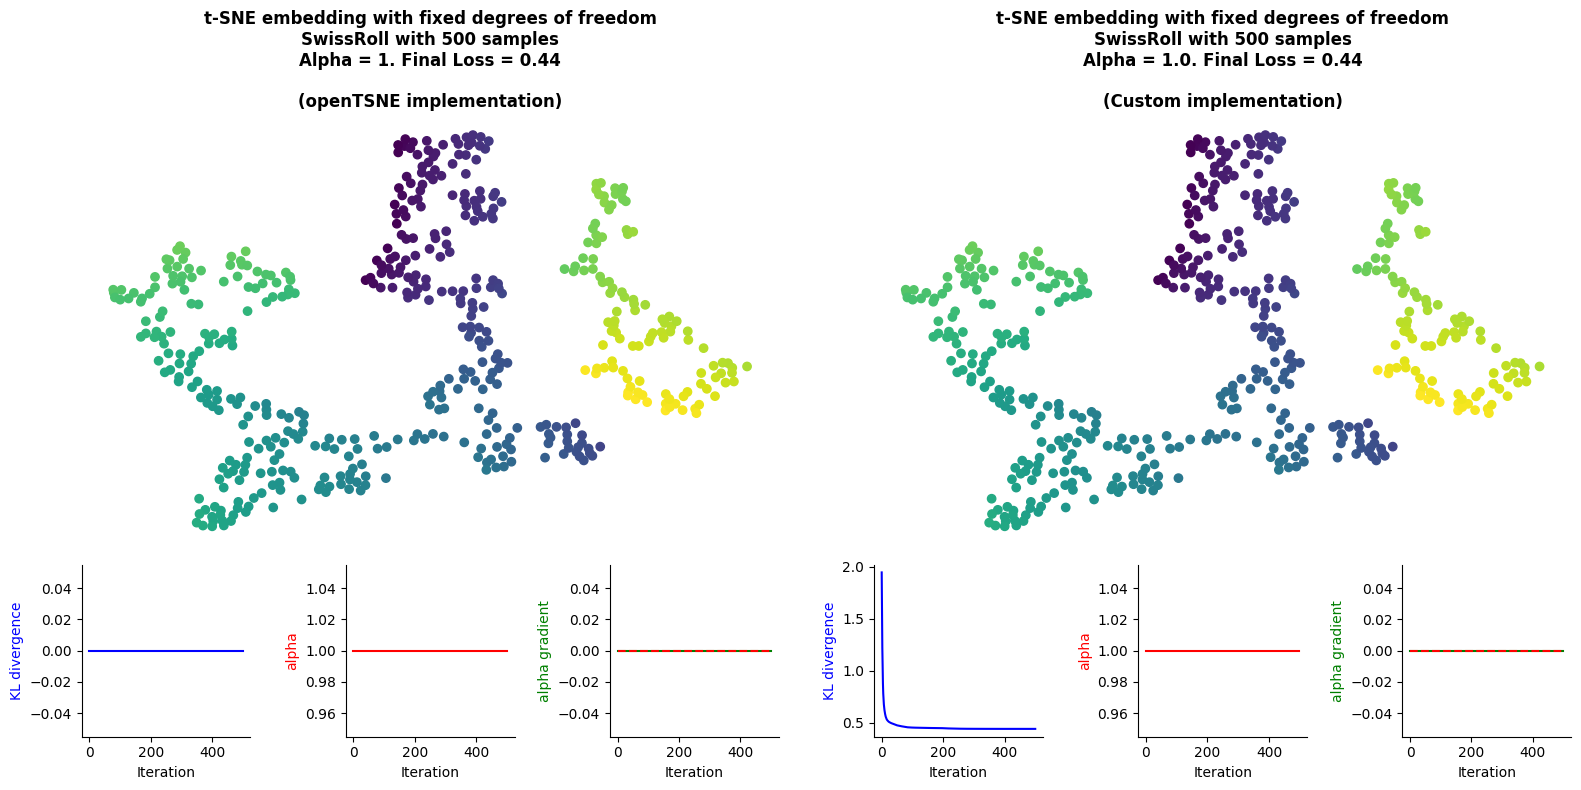

In [11]:
# Compare the two implementations side by side
utils.plot_side_by_side(data1=tsne_result, data2=tsne_result_custom, labels=colors, additional_title_1='(openTSNE implementation)', additional_title_2='(Custom implementation)')

### Digits

In [14]:
digits = load_digits(n_class=10)
digit_colors = sns.color_palette("Spectral", as_cmap=True)
X, color = digits.data, digits.target

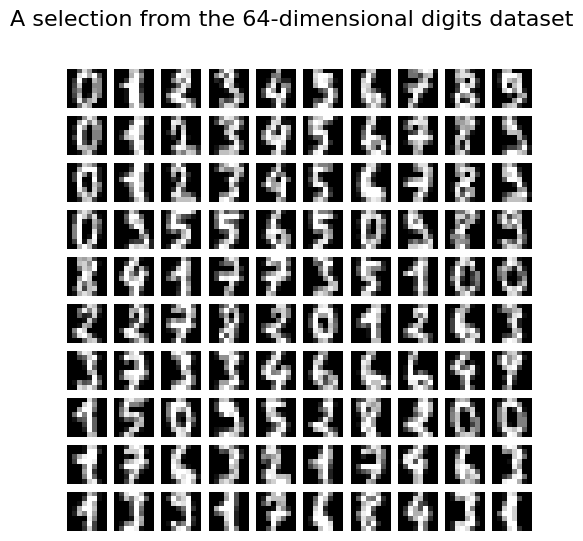

In [17]:
fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(X[idx].reshape((8, 8)), cmap="grey")
    ax.axis("off")
_ = fig.suptitle("A selection from the 64-dimensional digits dataset", fontsize=16)

In [19]:
tsne_result_custom = utils.tsne_with_dof_optimisation(X = X, n_iter=500, initial_alpha=INITIAL_ALPHA, dataset_name='Digits', verbose=True)

Initializing the t-SNE embedding...
Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 149.75 for 250 iterations...
Running optimization for 500 iterations...
Iteration 0 out of 500 done
Current KL divergence: 2.452001252421768
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 500 done
Current KL divergence: 2.256341822182648
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 500 done
Current KL divergence: 2.0628357288792127
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 500 done
Current KL divergence: 1.8908259524365647
Current alpha: 1.0
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 500 done
Current KL divergence: 1.7508768926743414
Current alpha: 1.0
Curre

In [20]:
tsne_result_openTSNE = utils.run_reference_tsne(X=X, n_iter=500, fixed_alpha =1, dataset_name='Digits')

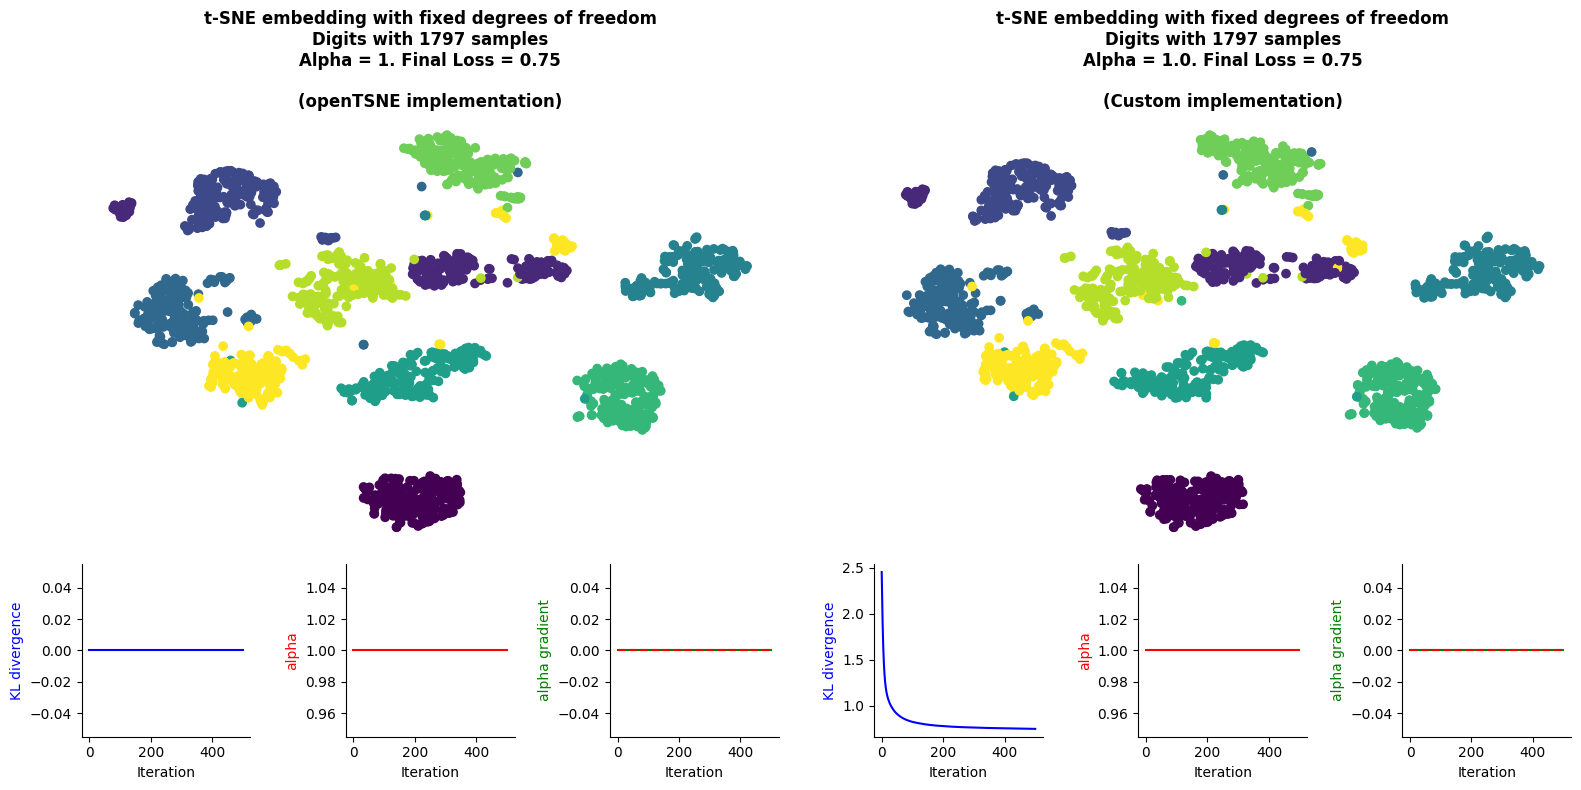

In [21]:
utils.plot_side_by_side(data1=tsne_result_openTSNE, data2=tsne_result_custom, labels=color, additional_title_1='(openTSNE implementation)', additional_title_2='(Custom implementation)')